# Change Detection Inference
Load a model checkpoint, visualize the binary change map for a specific image, and save it as a PNG.

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

from config import Config
from models.model import AdaptiveScratchFormerCD
from utils.train_utils import load_checkpoint

# ---------------------------------------------------------
# Configurations
# ---------------------------------------------------------
CKPT_PATH = "outputs/E0_baseline/best.ckpt"
IMAGE_NAME = "test_25_9.png"  # Make sure the extension is included if required
SAVE_PATH = "predicted_map.png" # Path to save the output PNG

dataset_root = Config().dataset_root
pre_path = os.path.join(dataset_root, "A", IMAGE_NAME)
post_path = os.path.join(dataset_root, "B", IMAGE_NAME)
label_path = os.path.join(dataset_root, "label", IMAGE_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ---------------------------------------------------------
# Load Model
# ---------------------------------------------------------
model = AdaptiveScratchFormerCD(exp_mode="E0")
ckpt = load_checkpoint(CKPT_PATH, model, optimizer=None)
model = model.to(device)
model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [4]:
# ---------------------------------------------------------
# Preprocess Images
# ---------------------------------------------------------
# Same transforms as training (Resize to 256x256 and ImageNet Normalization)
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_pre = Image.open(pre_path).convert("RGB")
img_post = Image.open(post_path).convert("RGB")

t_pre = transform(img_pre).unsqueeze(0).to(device)
t_post = transform(img_post).unsqueeze(0).to(device)

if os.path.exists(label_path):
    img_label = Image.open(label_path).convert("L")
    img_label = img_label.resize((256, 256), Image.Resampling.NEAREST)
else:
    img_label = None

In [8]:
# ---------------------------------------------------------
# Inference
# ---------------------------------------------------------
with torch.no_grad():
    # Inference in pure FP32 (no autocast) to match test.py
    logits = model(t_pre, t_post)
        
    # Sigmoid and threshold at 0.5
    preds = (torch.sigmoid(logits[0]) > 0.6).float().cpu().squeeze().numpy()

In [7]:
# ---------------------------------------------------------
# Save Predicted Change Map as PNG
# ---------------------------------------------------------
# Convert 0/1 predictions to 0/255 uint8 for saving
preds_img_array = (preds * 255).astype(np.uint8)
preds_pil_img = Image.fromarray(preds_img_array, mode="L")
preds_pil_img.save(SAVE_PATH)
print(f"Predicted change map saved successfully to: {SAVE_PATH}")

Predicted change map saved successfully to: predicted_map.png


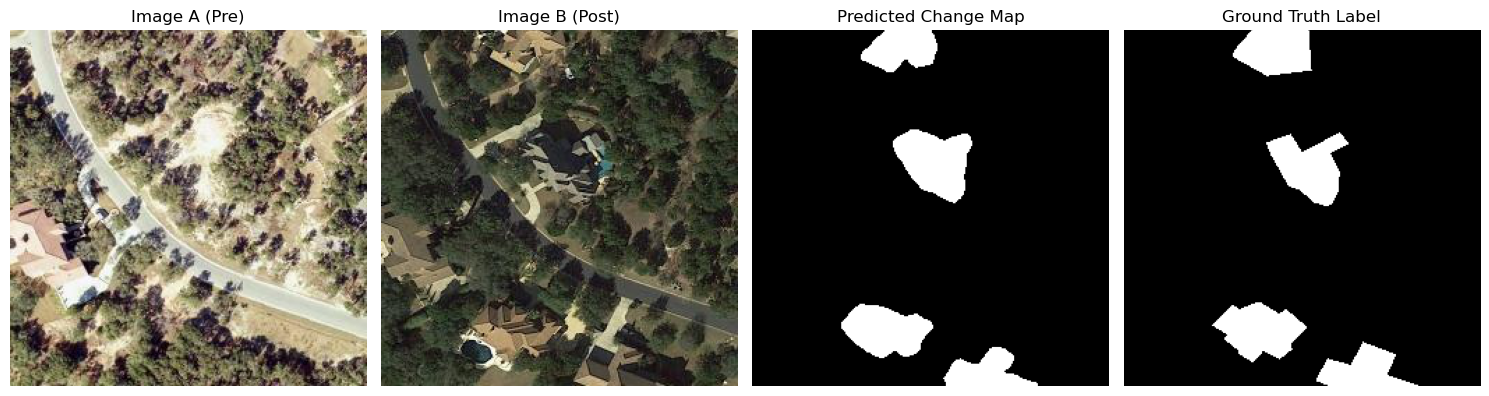

In [10]:
# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 4 if img_label else 3, figsize=(15, 5))

axes[0].imshow(img_pre.resize((256, 256)))
axes[0].set_title("Image A (Pre)")
axes[0].axis('off')

axes[1].imshow(img_post.resize((256, 256)))
axes[1].set_title("Image B (Post)")
axes[1].axis('off')

axes[2].imshow(preds, cmap='gray')
axes[2].set_title("Predicted Change Map")
axes[2].axis('off')

if img_label:
    axes[3].imshow(img_label, cmap='gray')
    axes[3].set_title("Ground Truth Label")
    axes[3].axis('off')

plt.tight_layout()
plt.show()